In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix, accuracy_score

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical

In [111]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

In [149]:
def clean_text(text):
  text = str(text).lower()
  text = re.sub(r"http\S+|www\S+|https\S+", '', text)
  text = re.sub(r"[^a-zA-Z\s]", '', text)
  text = re.sub(r"\s+", ' ', text).strip()
  return text

In [151]:
def plot_roc_multiclass(y_true_bin, y_prob, title):
  n_classes = y_true_bin.shape[1]
  plt.figure(figsize=(7,6))
  for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {i} ROC (AUC={roc_auc:.2f})')
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()

ROC CURVE FOR DATASET 1

In [139]:
def plot_roc_multiclass(y_true_bin, y_prob, title):
    n_classes = y_true_bin.shape[1]
    plt.figure(figsize=(7,6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} ROC (AUC={roc_auc:.2f})')
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()


In [140]:
summary = pd.DataFrame(columns=['Dataset', 'Model', 'Accuracy'])

DATASET 1

In [141]:
print("----- Dataset 1: Sentiment -----")
train_df = pd.read_csv('train.csv', encoding='latin-1')
test_df = pd.read_csv('test.csv', encoding='latin-1')


----- Dataset 1: Sentiment -----


In [142]:
train_df = train_df.dropna(subset=['sentiment','text'])
test_df = test_df.dropna(subset=['sentiment','text'])

In [143]:
train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

In [144]:
label_map = {'negative':0, 'neutral':1, 'positive':2}
train_df['label'] = train_df['sentiment'].map(label_map)
test_df['label'] = test_df['sentiment'].map(label_map)

In [145]:
train_df = train_df.dropna(subset=['label'])
test_df = test_df.dropna(subset=['label'])

In [146]:
train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

In [147]:
X_train_text = train_df['text'].values
y_train = train_df['label'].values
X_test_text = test_df['text'].values
y_test = test_df['label'].values

In [152]:
y_test_bin = label_binarize(y_test, classes=[0,1,2])

In [153]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

In [154]:
models = {
"Logistic Regression": LogisticRegression(max_iter=500),
"Naive Bayes": MultinomialNB(),
"SVM": OneVsRestClassifier(LinearSVC(max_iter=1000))
}

/tmp/ipython-input-885769695.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary = pd.concat([summary, new_row], ignore_index=True)


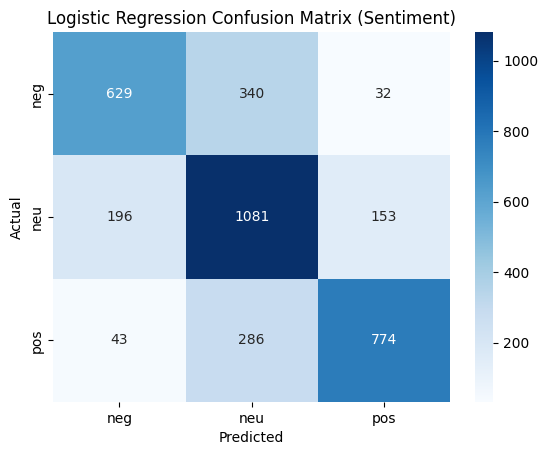

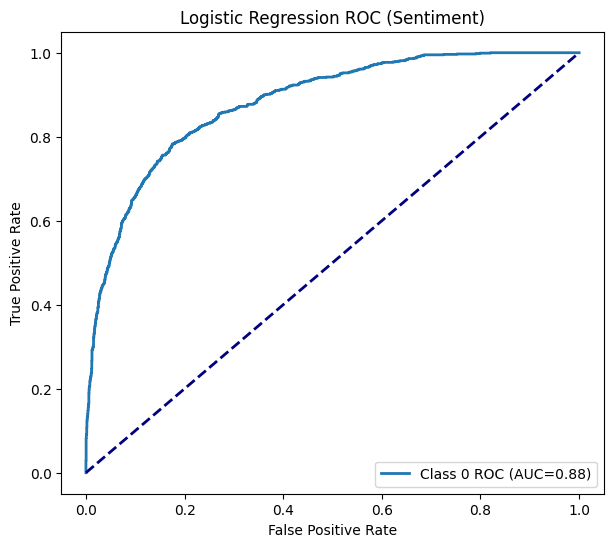

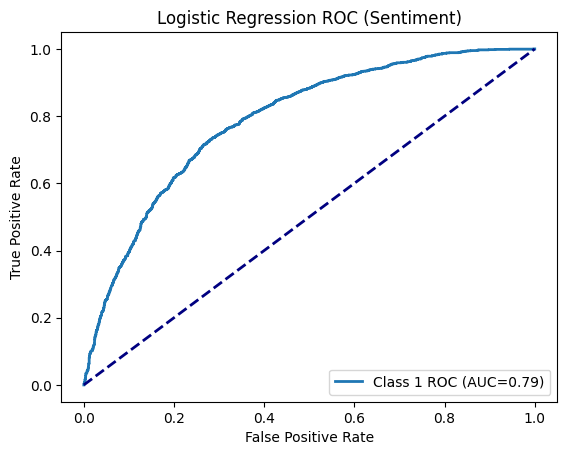

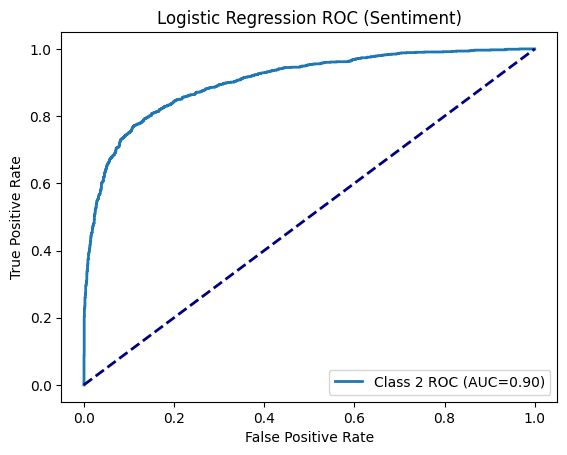

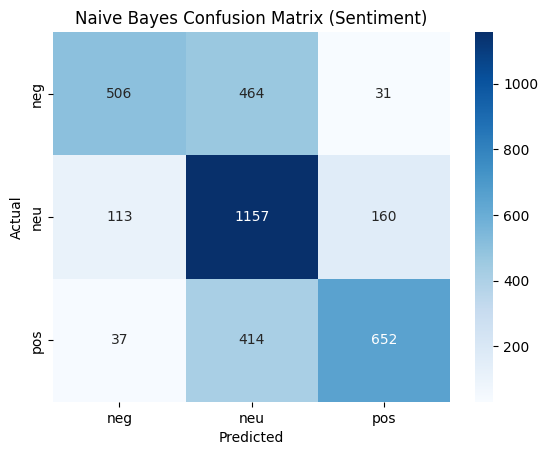

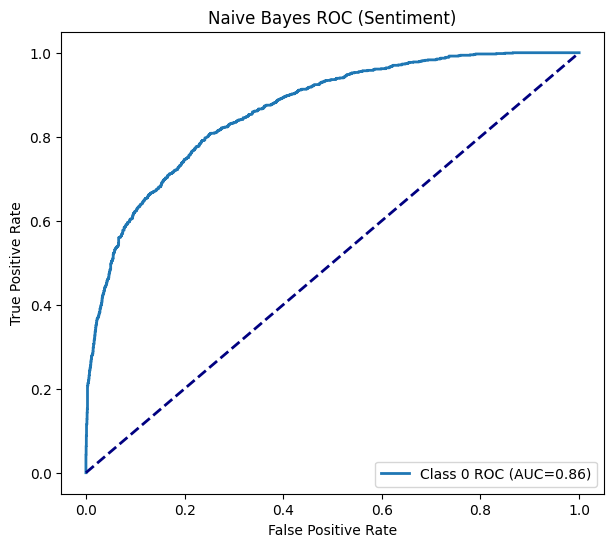

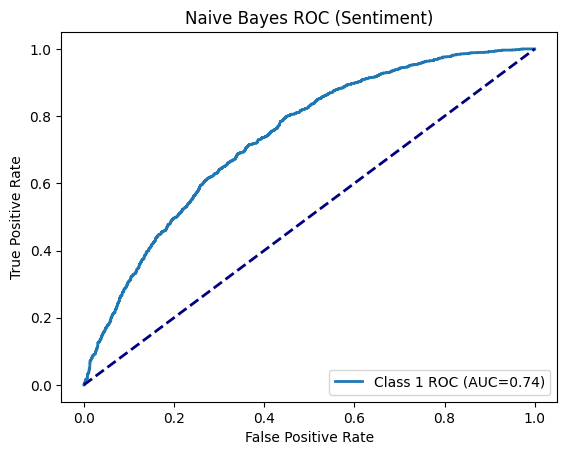

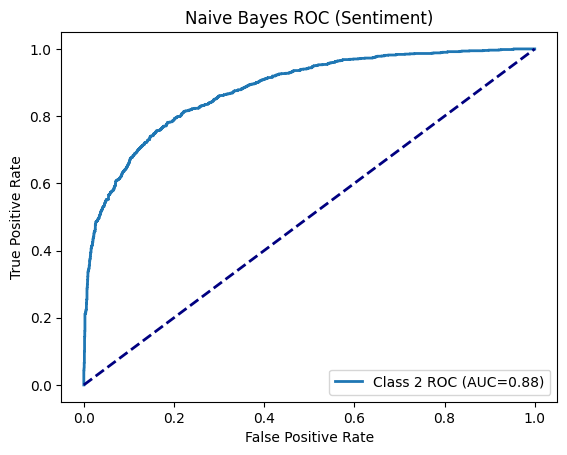

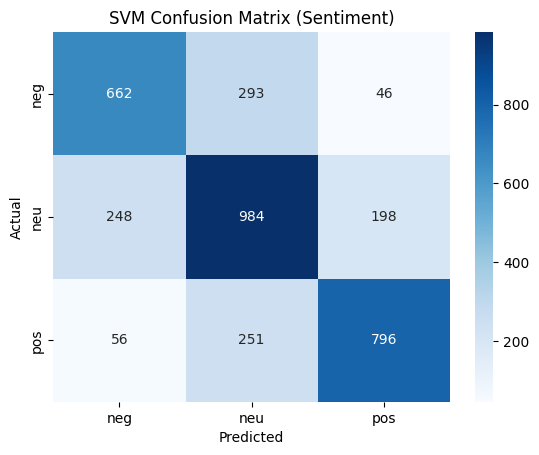

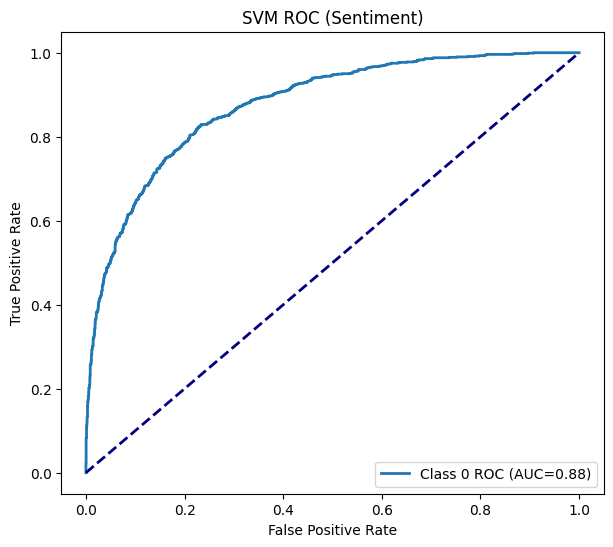

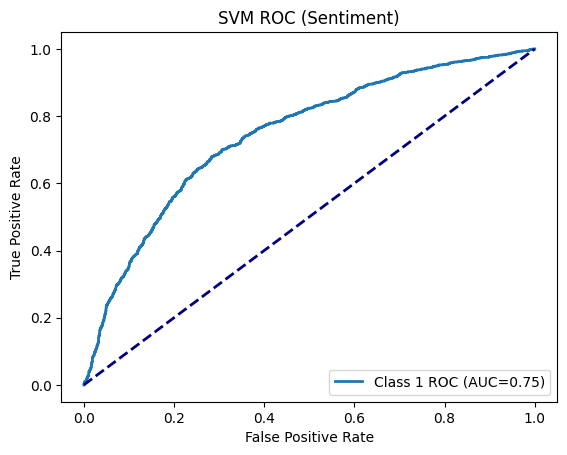

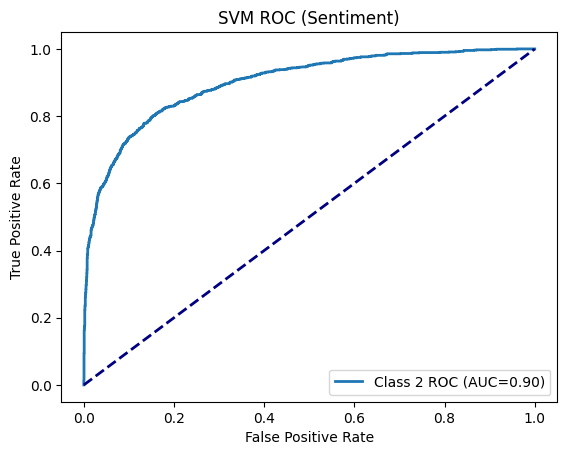

In [155]:
for name, model in models.items():
  model.fit(X_train_tfidf, y_train)
  y_pred = model.predict(X_test_tfidf)
  acc = accuracy_score(y_test, y_pred)
  new_row = pd.DataFrame({'Dataset':['Sentiment'], 'Model':[name], 'Accuracy':[acc]})
  summary = pd.concat([summary, new_row], ignore_index=True)
  plot_confusion(y_test, y_pred, f"{name} Confusion Matrix (Sentiment)", ['neg','neu','pos'])
  # ROC Curve (only for models with predict_proba)
  if hasattr(model, "predict_proba"):
    y_prob = model.predict_proba(X_test_tfidf)
    plot_roc_multiclass(y_test_bin, y_prob, f"{name} ROC (Sentiment)")
  else:
    # Use decision_function for SVM
    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_tfidf)
        if y_score.ndim == 1:  # binary case
            y_score = np.vstack([1-y_score, y_score]).T
        plot_roc_multiclass(y_test_bin, y_score, f"{name} ROC (Sentiment)")

In [156]:
max_words = 5000
max_len = 100
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_text)
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [157]:
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

In [158]:
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=max_words, output_dim=64))
model_lstm.add(Bidirectional(LSTM(64)))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(3, activation='softmax'))
model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [159]:
model_lstm.fit(X_train_pad, y_train_cat, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 105s 498ms/step - accuracy: 0.4679 - loss: 1.0138 - val_accuracy: 0.6776 - val_loss: 0.7383
Epoch 2/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 66s 341ms/step - accuracy: 0.7149 - loss: 0.6833 - val_accuracy: 0.7012 - val_loss: 0.6926
Epoch 3/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 61s 315ms/step - accuracy: 0.7632 - loss: 0.5874 - val_accuracy: 0.7012 - val_loss: 0.6951
Epoch 4/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 62s 318ms/step - accuracy: 0.7907 - loss: 0.5340 - val_accuracy: 0.7111 - val_loss: 0.7211
Epoch 5/5
194/194 ━━━━━━━━━━━━━━━━━━━━ 63s 327ms/step - accuracy: 0.8092 - loss: 0.4985 - val_accuracy: 0.6903 - val_loss: 0.7519


111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


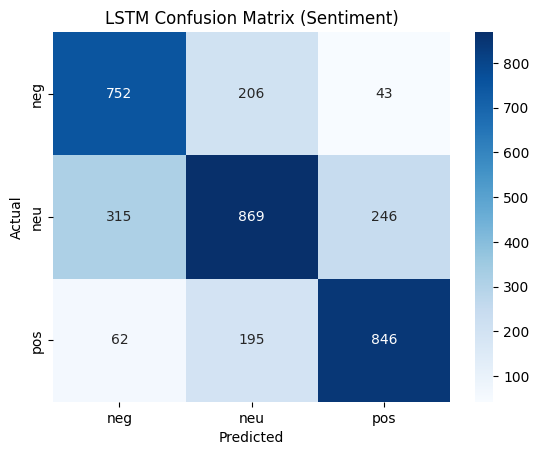

In [160]:
y_pred_lstm = np.argmax(model_lstm.predict(X_test_pad), axis=1)
acc_lstm = accuracy_score(y_test, y_pred_lstm)
new_row_lstm = pd.DataFrame({'Dataset': ['Sentiment'], 'Model': ['LSTM'], 'Accuracy': [acc_lstm]})
summary = pd.concat([summary, new_row_lstm], ignore_index=True)
plot_confusion(y_test, y_pred_lstm, "LSTM Confusion Matrix (Sentiment)", ['neg','neu','pos'])

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step


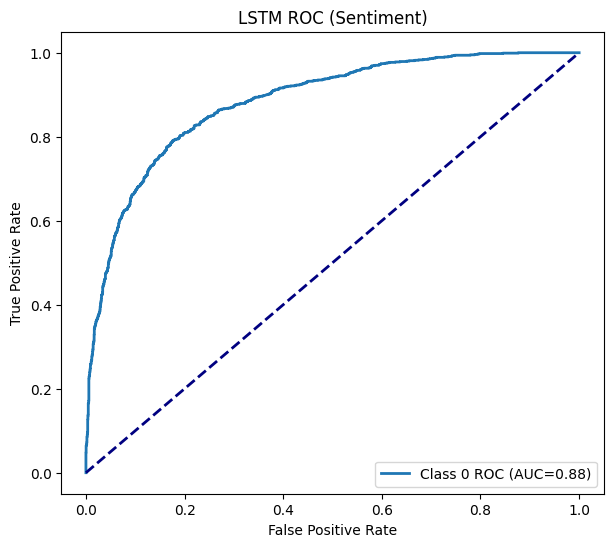

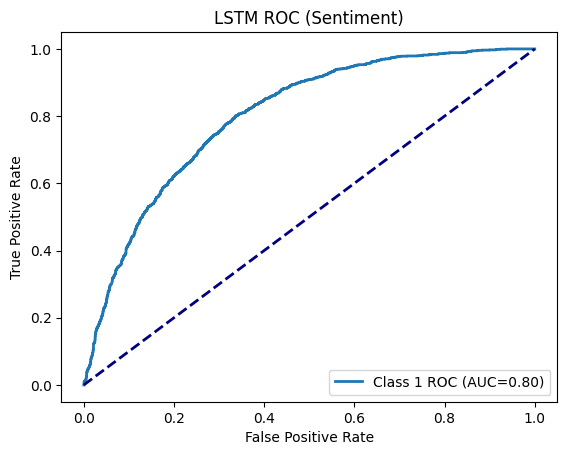

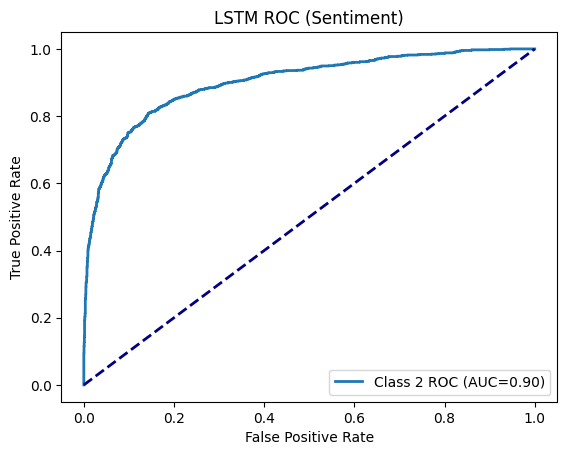

In [161]:
y_prob_lstm = model_lstm.predict(X_test_pad)
plot_roc_multiclass(y_test_bin, y_prob_lstm, "LSTM ROC (Sentiment)")

**DATASET 02**



In [47]:
print("----- Dataset 2: SMS Spam -----")
sms_df = pd.read_csv('spam.csv', encoding='latin-1')
sms_df = sms_df[['v1','v2']]
sms_df.columns = ['label', 'text']

----- Dataset 2: SMS Spam -----


In [52]:
sms_df = sms_df.dropna(subset=['label','text'])

sms_df['text'] = sms_df['text'].apply(clean_text)
sms_df['label'] = sms_df['label'].map({'ham':0,'spam':1})

In [53]:
X_sms = sms_df['text'].values
y_sms = sms_df['label'].values


ROC CURVE FOR DATASET 2

In [92]:
# ROC helper for binary classification (SMS Spam)
def plot_roc_binary(y_true, y_scores, title):
    from sklearn.metrics import roc_curve, auc
    import matplotlib.pyplot as plt

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC={roc_auc:.2f})')
    plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()


In [56]:
print(sms_df.shape)
print(sms_df.head())


(0, 2)
Empty DataFrame
Columns: [label, text]
Index: []


In [58]:
# Load CSV with latin-1 encoding
sms_df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only the first two columns: label and text
sms_df = sms_df[['v1','v2']].copy()
sms_df.columns = ['label','text']

# Drop rows with missing values in either column
sms_df = sms_df.dropna(subset=['label','text'])

# Clean the text
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"[^a-zA-Z\s]", '', text)
    text = re.sub(r"\s+", ' ', text).strip()
    return text

sms_df['text'] = sms_df['text'].apply(clean_text)

# Map labels to integers
sms_df['label'] = sms_df['label'].map({'ham':0, 'spam':1})

# Check the dataset
print(sms_df.shape)
print(sms_df.head())


(5572, 2)
   label                                               text
0      0  go until jurong point crazy available only in ...
1      0                            ok lar joking wif u oni
2      1  free entry in a wkly comp to win fa cup final ...
3      0        u dun say so early hor u c already then say
4      0  nah i dont think he goes to usf he lives aroun...


In [59]:
from sklearn.model_selection import train_test_split

X_sms = sms_df['text'].values
y_sms = sms_df['label'].values

X_train_sms, X_test_sms, y_train_sms, y_test_sms = train_test_split(
    X_sms, y_sms, test_size=0.2, random_state=42
)


In [60]:
vectorizer_sms = TfidfVectorizer(max_features=5000)
X_train_tfidf_sms = vectorizer_sms.fit_transform(X_train_sms)
X_test_tfidf_sms = vectorizer_sms.transform(X_test_sms)

MODELS ROC CURVE AND CONFUSION MATRIX

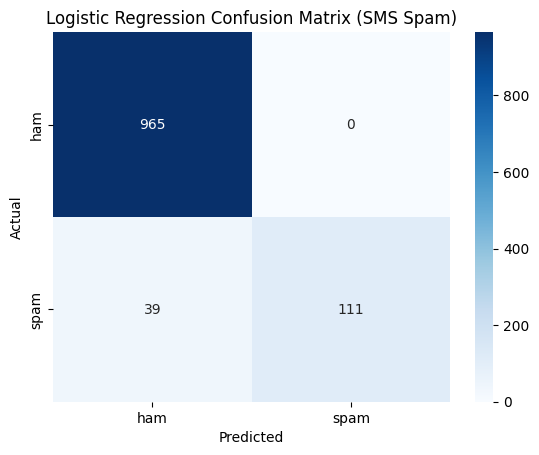

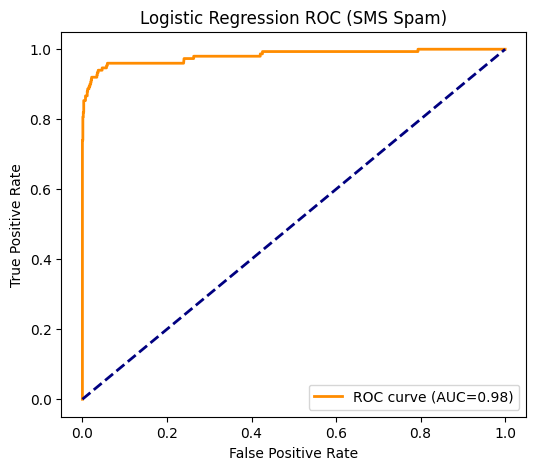

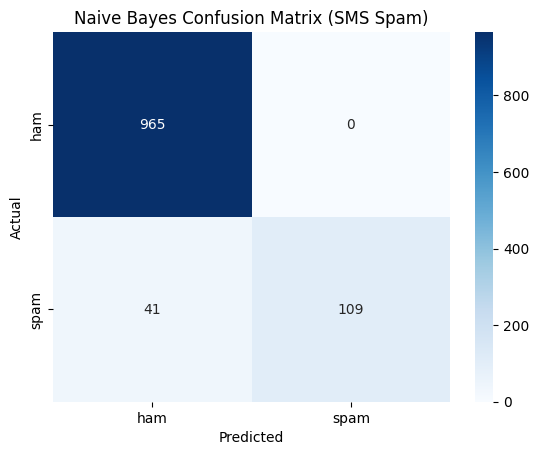

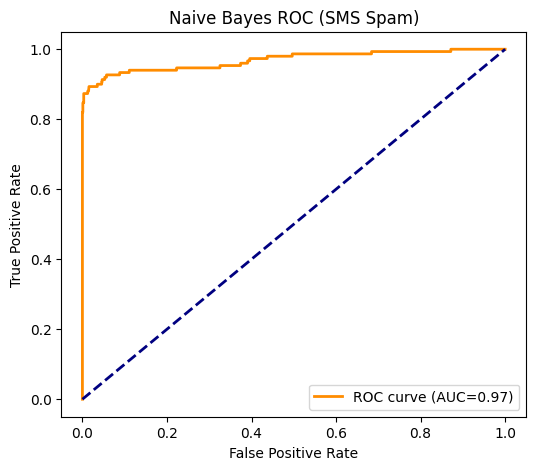

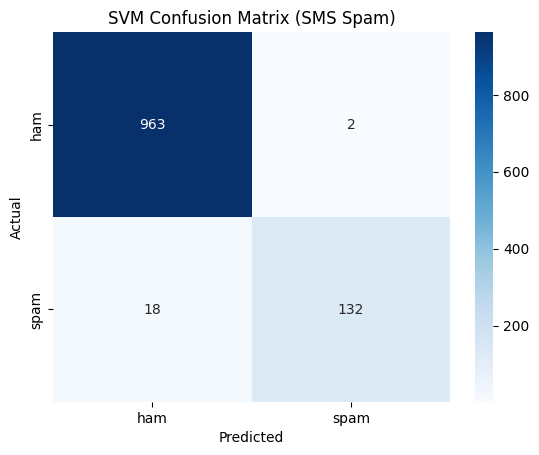

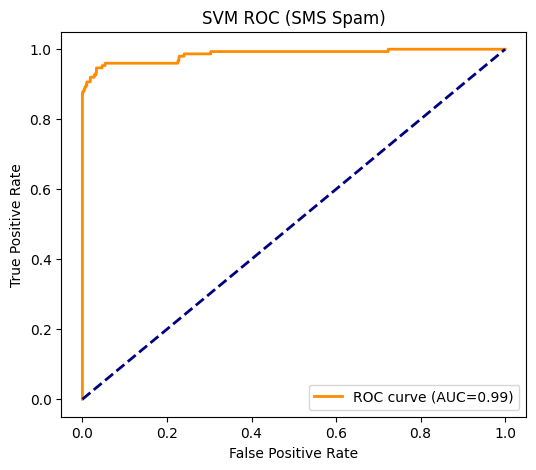

In [93]:
for name, model in models.items():
    model.fit(X_train_tfidf_sms, y_train_sms)
    y_pred = model.predict(X_test_tfidf_sms)
    acc = accuracy_score(y_test_sms, y_pred)

    new_row = pd.DataFrame({'Dataset':['SMS Spam'], 'Model':[name], 'Accuracy':[acc]})
    summary = pd.concat([summary, new_row], ignore_index=True)

    plot_confusion(y_test_sms, y_pred, f"{name} Confusion Matrix (SMS Spam)", ['ham','spam'])
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test_tfidf_sms)[:,1]
    else:
        y_scores = model.decision_function(X_test_tfidf_sms)
    plot_roc_binary(y_test_sms, y_scores, f"{name} ROC (SMS Spam)")

In [63]:
tokenizer_sms = Tokenizer(num_words=max_words)
tokenizer_sms.fit_on_texts(X_train_sms)
X_train_seq_sms = tokenizer_sms.texts_to_sequences(X_train_sms)
X_test_seq_sms = tokenizer_sms.texts_to_sequences(X_test_sms)
X_train_pad_sms = pad_sequences(X_train_seq_sms, maxlen=max_len)
X_test_pad_sms = pad_sequences(X_test_seq_sms, maxlen=max_len)

In [64]:
y_train_cat_sms = to_categorical(y_train_sms, num_classes=2)
y_test_cat_sms = to_categorical(y_test_sms, num_classes=2)

In [76]:
model_lstm_sms = Sequential()
model_lstm_sms.add(Embedding(input_dim=max_words, output_dim=64))  # removed input_length
model_lstm_sms.add(Bidirectional(LSTM(64)))
model_lstm_sms.add(Dropout(0.5))
model_lstm_sms.add(Dense(2, activation='softmax'))
model_lstm_sms.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [80]:
# Example: more epochs, larger LSTM, longer sequence
max_len = 150
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=max_words, output_dim=128))  # larger embedding
model_lstm.add(Bidirectional(LSTM(128, return_sequences=True)))
model_lstm.add(Dropout(0.5))
model_lstm.add(Bidirectional(LSTM(64)))
model_lstm.add(Dense(3, activation='softmax'))
model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model_lstm.fit(X_train_pad, y_train_cat, epochs=15, batch_size=128, validation_split=0.1)


Epoch 1/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.4961 - loss: 0.9794 - val_accuracy: 0.6893 - val_loss: 0.7162
Epoch 2/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.7426 - loss: 0.6276 - val_accuracy: 0.7254 - val_loss: 0.6646
Epoch 3/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.7928 - loss: 0.5356 - val_accuracy: 0.7039 - val_loss: 0.6984
Epoch 4/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.8116 - loss: 0.4811 - val_accuracy: 0.7264 - val_loss: 0.7221
Epoch 5/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8413 - loss: 0.4263 - val_accuracy: 0.7159 - val_loss: 0.7621
Epoch 6/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.8637 - loss: 0.3762 - val_accuracy: 0.7006 - val_loss: 0.8395
Epoch 7/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.8866 - loss: 0.3252 - val_accuracy: 0.6904 - val_loss: 0.8887
Epoch 8/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.8935 - loss: 0.2934 - val_accu

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step


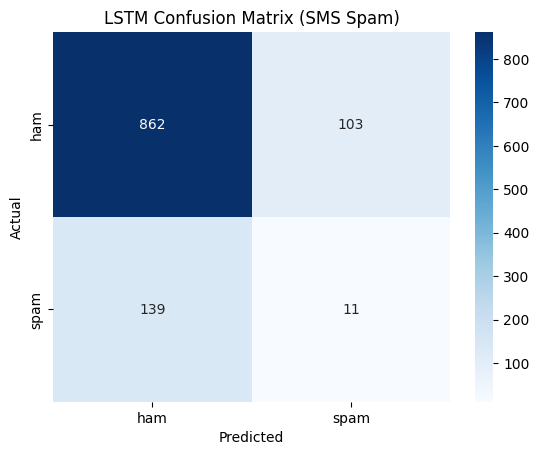

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step


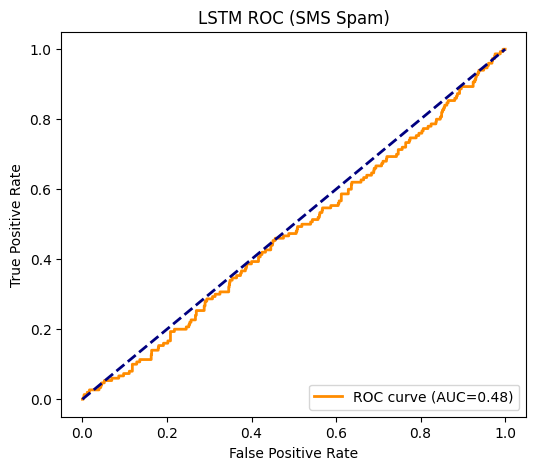

In [100]:
y_pred_lstm_sms = np.argmax(model_lstm_sms.predict(X_test_pad_sms), axis=1)
acc_lstm_sms = accuracy_score(y_test_sms, y_pred_lstm_sms)

# Add to summary
new_row = pd.DataFrame({'Dataset':['SMS Spam'], 'Model':['LSTM'], 'Accuracy':[acc_lstm_sms]})
summary = pd.concat([summary, new_row], ignore_index=True)

# Confusion matrix
plot_confusion(y_test_sms, y_pred_lstm_sms, "LSTM Confusion Matrix (SMS Spam)", ['ham','spam'])

# ROC curve
plot_roc_binary(y_test_sms, model_lstm_sms.predict(X_test_pad_sms)[:,1], "LSTM ROC (SMS Spam)")


In [101]:
print("===== Accuracy Summary =====")
print(summary)

===== Accuracy Summary =====
      Dataset                Model  Accuracy
0   Sentiment  Logistic Regression  0.704018
1   Sentiment          Naive Bayes  0.655065
2   Sentiment                  SVM  0.691002
3   Sentiment  Logistic Regression  0.704018
4   Sentiment          Naive Bayes  0.655065
5   Sentiment                  SVM  0.691002
6   Sentiment                 LSTM  0.404641
7    SMS Spam  Logistic Regression  0.965022
8    SMS Spam          Naive Bayes  0.963229
9    SMS Spam                  SVM  0.982063
10   SMS Spam                 LSTM  0.782960
11   SMS Spam                 LSTM  0.782960
12  Sentiment  Logistic Regression  0.704018
13  Sentiment  Logistic Regression  0.704018
14  Sentiment  Logistic Regression  0.704018
15  Sentiment  Logistic Regression  0.704018
16   SMS Spam  Logistic Regression  0.965022
17   SMS Spam          Naive Bayes  0.963229
18   SMS Spam                  SVM  0.982063
19  Sentiment  Logistic Regression  0.704018
20  Sentiment  Logistic Re

In [177]:
# ---------- Interactive Input ----------

def predict_sentiment(text):
    text_clean = clean_text(text)
    seq = tokenizer.texts_to_sequences([text_clean])
    pad = pad_sequences(seq, maxlen=max_len)
    pred = np.argmax(model_lstm.predict(pad), axis=1)
    label_map_inv = {0:'negative', 1:'neutral', 2:'positive'}
    return label_map_inv[pred[0]]

def predict_sms(text):
    text_clean = clean_text(text)
    seq = tokenizer_sms.texts_to_sequences([text_clean])
    pad = pad_sequences(seq, maxlen=max_len)
    pred = np.argmax(model_lstm_sms.predict(pad), axis=1)[0]
    return 'ham' if pred==0 else 'spam'

while True:
    print("\nSelect option:")
    print("1. Sentiment Analysis")
    print("2. SMS Spam Detection")
    print("3. Exit")
    choice = input("Enter choice (1/2/3): ").strip()

    if choice == '1':
        user_input = input("Enter a sentence: ")
        result = predict_sentiment(user_input)
        print(f"Sentiment Prediction: {result}")

    elif choice == '2':
        user_input = input("Enter an SMS text: ")
        result = predict_sms(user_input)
        print(f"SMS Prediction: {result}")

    elif choice == '3':
        print("Exiting...")
        break
    else:
        print("Invalid choice. Try again.")


Select option:
1. Sentiment Analysis
2. SMS Spam Detection
3. Exit
Enter choice (1/2/3): 1
Enter a sentence: hello
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Sentiment Prediction: neutral

Select option:
1. Sentiment Analysis
2. SMS Spam Detection
3. Exit
Enter choice (1/2/3): 1
Enter a sentence: how are you
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Sentiment Prediction: neutral

Select option:
1. Sentiment Analysis
2. SMS Spam Detection
3. Exit
Enter choice (1/2/3): 1
Enter a sentence: i am happy to say i have completed my NLP project today
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Sentiment Prediction: positive

Select option:
1. Sentiment Analysis
2. SMS Spam Detection
3. Exit
Enter choice (1/2/3): 1
Enter a sentence: it took so much of time to train
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Sentiment Prediction: negative

Select option:
1. Sentiment Analysis
2. SMS Spam Detection
3. Exit
Enter choice (1/2/3): 2
Enter an SMS text: Hey! Are we still meeting for lunch today?
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [165]:
def predict_sentiment_classical(text):
    """
    For classical ML models trained on TF-IDF vectors.
    Handles multi-class sentiment (negative, neutral, positive).
    """
    text_cleaned = clean_text(text)
    vector = vectorizer.transform([text_cleaned])  # same TF-IDF vectorizer used for training
    # Use a classical model for prediction, e.g., Logistic Regression
    pred_class = models['Logistic Regression'].predict(vector)
    # If binary model, pred_class may be 0/1; for multi-class, take argmax
    if pred_class.ndim > 1:
        pred_class = np.argmax(pred_class, axis=1)[0]
    else:
        pred_class = int(pred_class)

    label_map_inv = {0: "Negative 😡", 1: "Neutral 😐", 2: "Positive 😊"}
    return label_map_inv.get(pred_class, "Unknown")

def predict_sentiment_lstm(text):
    """
    For LSTM model trained on padded sequences.
    """
    text_cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([text_cleaned])
    pad = pad_sequences(seq, maxlen=max_len)
    pred_class = np.argmax(model_lstm.predict(pad), axis=1)[0]
    label_map_inv = {0: "Negative 😡", 1: "Neutral 😐", 2: "Positive 😊"}
    return label_map_inv.get(pred_class, "Unknown")

In [169]:
sentence = input("enter a sentence :")
print("Classical ML Prediction:", predict_sentiment_classical(sentence))
print("LSTM Prediction:", predict_sentiment_lstm(sentence))


enter a sentence :what  a wonderful day
Classical ML Prediction: Positive 😊
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
LSTM Prediction: Positive 😊


/tmp/ipython-input-4289750926.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_class = int(pred_class)
